In [1]:
# 0 Starter Code

# You must run this code and use this dataset for all questions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
num_students = 50

# Student data
student_ids = np.arange(201, 201 + num_students)
student_ages = np.random.randint(15, 22, num_students)
student_scores = np.random.randint(40, 100, num_students)
student_attendance = np.random.randint(60, 100, num_students)  # percentage

departments_list = [
    "Science",
    "Commerce",
    "Arts",
    "Computer Science",
    "Mathematics",
    "English",
    "Physics",
    "Chemistry",
    "Biology",
    "Economics"
]

student_departments = np.random.choice(departments_list, num_students)

grade_conditions = [
    student_scores >= 80,
    (student_scores >= 65) & (student_scores < 80),
    (student_scores >= 50) & (student_scores < 65),
    student_scores < 50
]
grade_values = ["A", "B", "C", "F"]
student_grades = np.select(grade_conditions, grade_values, default="F")

# Create DataFrame
data = pd.DataFrame({
    "student_id": student_ids,
    "student_age": student_ages,
    "score": student_scores,
    "attendance": student_attendance,
    "department": student_departments,
    "grade": student_grades
})

# Save dataset
data.to_csv("school_data.csv", index=False)

## Problem 1

In [2]:
score_arr = data["score"].to_numpy().copy()
attendance_arr = data["attendance"].to_numpy().copy()

In [7]:
print("Score:")
print(score_arr)

Score:
[76 90 46 60 48 78 57 43 64 99 53 89 97 48 65 92 41 59 67 86 99 46 83 47
 86 74 53 56 75 89 79 43 41 45 93 81 43 93 68 57 65 83 73 49 75 53 70 87
 54 47]


In [6]:
print("Attendance:")
print(attendance_arr)

Attendance:
[73 82 99 80 75 77 83 85 84 88 74 60 84 66 68 83 60 67 83 70 76 67 94 94
 92 64 98 87 66 68 67 71 93 92 82 83 96 94 99 81 86 94 60 94 96 73 62 60
 64 85]


In [9]:
## Score
print("Data Type:", score_arr.dtype)
print("Dimensions:", score_arr.ndim)
print("Shape:", score_arr.shape)
print("Elements:", score_arr.size)

Data Type: int32
Dimensions: 1
Shape: (50,)
Elements: 50


In [10]:
## Attendance
print("Data Type:", attendance_arr.dtype)
print("Dimensions:", attendance_arr.ndim)
print("Shape:", attendance_arr.shape)
print("Elements:", attendance_arr.size)

Data Type: int32
Dimensions: 1
Shape: (50,)
Elements: 50


## Problem 2

In [14]:
# max min score
maxx = np.max(score_arr)
mini = np.min(score_arr)

print("Maxi Score:", maxx)
print("Mini Score:", mini)

Maxi Score: 99
Mini Score: 41


In [15]:
# average
avg_score = np.mean(score_arr)
avg_attendance = np.mean(attendance_arr)

print("Average Score:", avg_score)
print("Average Attendance:", avg_attendance)

Average Score: 67.3
Average Attendance: 79.58


In [16]:
filtered = score_arr[score_arr > avg_score]
print(filtered)

[76 90 78 99 89 97 92 86 99 83 86 74 75 89 79 93 81 93 68 83 73 75 70 87]


## Problem 3

In [17]:
df = pd.read_csv("school_data.csv")

In [18]:
df

,student_id,student_age,score,attendance,department,grade
0,201,21,76,73,Physics,B
1,202,18,90,82,Physics,A
2,203,19,46,99,Biology,F
3,204,21,60,80,Economics,C
4,205,17,48,75,Economics,F
5,206,19,78,77,Arts,B
6,207,19,57,83,Physics,C
7,208,21,43,85,Science,F
8,209,16,64,84,Computer Science,C
9,210,17,99,88,Computer Science,A


In [19]:
print(df.head(3))

   student_id  student_age  score  attendance department grade
0         201           21     76          73    Physics     B
1         202           18     90          82    Physics     A
2         203           19     46          99    Biology     F


In [20]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   student_id   50 non-null     int64 
 1   student_age  50 non-null     int64 
 2   score        50 non-null     int64 
 3   attendance   50 non-null     int64 
 4   department   50 non-null     object
 5   grade        50 non-null     object
dtypes: int64(4), object(2)
memory usage: 2.5+ KB
None


In [21]:
print(df.describe())

       student_id  student_age      score  attendance
count    50.00000    50.000000  50.000000   50.000000
mean    225.50000    18.280000  67.300000   79.580000
std      14.57738     1.852081  18.248008   12.163998
min     201.00000    15.000000  41.000000   60.000000
25%     213.25000    17.000000  50.000000   68.000000
50%     225.50000    18.000000  66.000000   82.000000
75%     237.75000    20.000000  83.000000   91.000000
max     250.00000    21.000000  99.000000   99.000000


In [22]:
filter_df = df[["student_id", "student_age", "department", "grade"]].copy()

filter_df

,student_id,student_age,department,grade
0,201,21,Physics,B
1,202,18,Physics,A
2,203,19,Biology,F
3,204,21,Economics,C
4,205,17,Economics,F
5,206,19,Arts,B
6,207,19,Physics,C
7,208,21,Science,F
8,209,16,Computer Science,C
9,210,17,Computer Science,A


In [27]:
agefiltered = filter_df[(filter_df["student_age"] >= 16) & (filter_df["student_age"] <= 20)]
sortdf = agefiltered.sort_values(by="student_id")

In [28]:
sortdf

,student_id,student_age,department,grade
1,202,18,Physics,A
2,203,19,Biology,F
4,205,17,Economics,F
5,206,19,Arts,B
6,207,19,Physics,C
8,209,16,Computer Science,C
9,210,17,Computer Science,A
11,212,17,Physics,A
12,213,17,Physics,A
13,214,19,Computer Science,F


In [30]:
print(sortdf.tail(3))

    student_id  student_age department grade
45         246           18    Biology     C
47         248           18    Science     A
49         250           17  Economics     F


## Problem 4

In [41]:
copydf = df.copy()

copydf["score"] = copydf["score"].astype(float)

copydf["previous_score"] = copydf["score"]

copydf.loc[copydf["department"] == "Computer Science", "score"] = (copydf["score"] * 1.10)

copydf.loc[copydf["department"] == "Mathematics", "score"] = (copydf["score"] * 1.10)

copydf.loc[ (copydf["department"] != "Computer Science") & (copydf["department"] != "Mathematics"),"score"] = copydf["score"] * 1.05

In [42]:
copydf

,student_id,student_age,score,attendance,department,grade,previous_score
0,201,21,79.80,73,Physics,B,76.0
1,202,18,94.50,82,Physics,A,90.0
2,203,19,48.30,99,Biology,F,46.0
3,204,21,63.00,80,Economics,C,60.0
4,205,17,50.40,75,Economics,F,48.0
5,206,19,81.90,77,Arts,B,78.0
6,207,19,59.85,83,Physics,C,57.0
7,208,21,45.15,85,Science,F,43.0
8,209,16,70.40,84,Computer Science,C,64.0
9,210,17,108.90,88,Computer Science,A,99.0


In [43]:
copydf["score"] = copydf["score"].clip(upper=100)

copydf["new_score"] = copydf["score"].round(2)

copydf["score_increase"] = (copydf["new_score"] - copydf["previous_score"]).round(2)

copydf

,student_id,student_age,score,attendance,department,grade,previous_score,new_score,score_increase
0,201,21,79.80,73,Physics,B,76.0,79.80,3.80
1,202,18,94.50,82,Physics,A,90.0,94.50,4.50
2,203,19,48.30,99,Biology,F,46.0,48.30,2.30
3,204,21,63.00,80,Economics,C,60.0,63.00,3.00
4,205,17,50.40,75,Economics,F,48.0,50.40,2.40
5,206,19,81.90,77,Arts,B,78.0,81.90,3.90
6,207,19,59.85,83,Physics,C,57.0,59.85,2.85
7,208,21,45.15,85,Science,F,43.0,45.15,2.15
8,209,16,70.40,84,Computer Science,C,64.0,70.40,6.40
9,210,17,100.00,88,Computer Science,A,99.0,100.00,1.00


In [44]:
result = copydf[["student_id","department","previous_score","new_score","score_increase"]]

result

,student_id,department,previous_score,new_score,score_increase
0,201,Physics,76.0,79.80,3.80
1,202,Physics,90.0,94.50,4.50
2,203,Biology,46.0,48.30,2.30
3,204,Economics,60.0,63.00,3.00
4,205,Economics,48.0,50.40,2.40
5,206,Arts,78.0,81.90,3.90
6,207,Physics,57.0,59.85,2.85
7,208,Science,43.0,45.15,2.15
8,209,Computer Science,64.0,70.40,6.40
9,210,Computer Science,99.0,100.00,1.00


# Problem 5

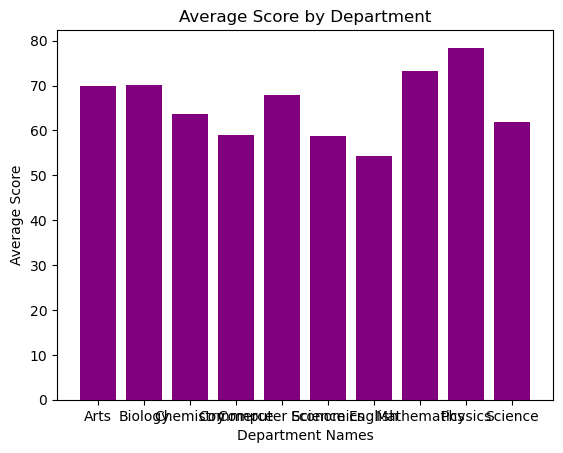

In [49]:
copydf = df.copy()

avg = copydf.groupby("department")["score"].mean()

plt.bar(avg.index, avg.values, color="purple")

plt.xlabel("Department Names")
plt.ylabel("Average Score")
plt.title("Average Score by Department")

plt.show()

## Problem 6

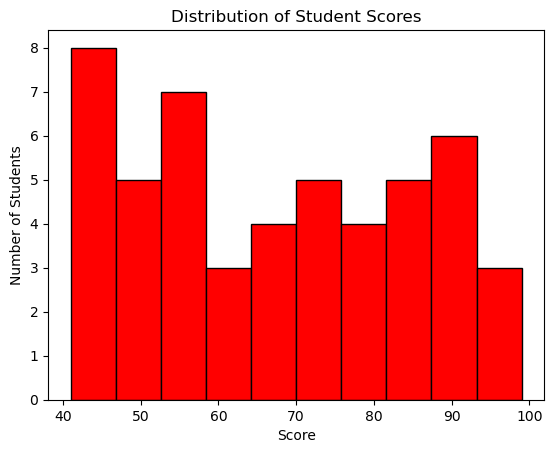

In [59]:
copydf = df.copy()
plt.hist(copydf["score"], bins=10, color="red", edgecolor="black")

plt.title("Distribution of Student Scores")
plt.xlabel("Score")
plt.ylabel("Number of Students")

plt.show()



## Problem 7

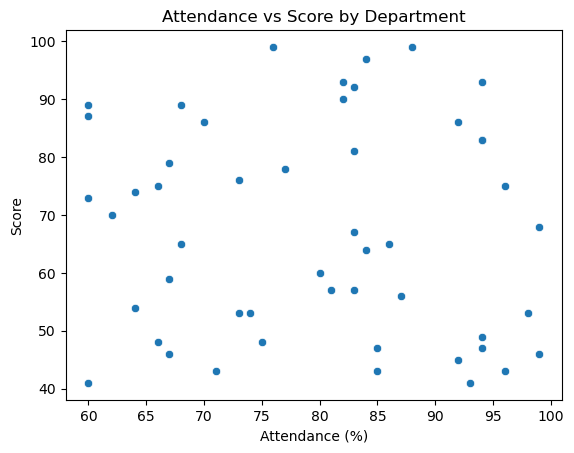

In [71]:
copydf = df.copy()

sns.scatterplot(data=copydf,x='attendance',y='score')

plt.xlabel('Attendance (%)')
plt.ylabel('Score')
plt.title('Attendance vs Score by Department')

plt.show()

## Problem 8

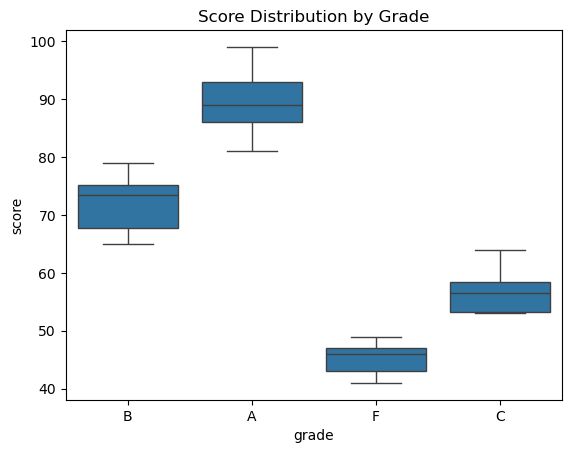

In [63]:
sns.boxplot(x='grade', y='score', data=copydf)

plt.title('Score Distribution by Grade')

plt.show()

## Problem 9

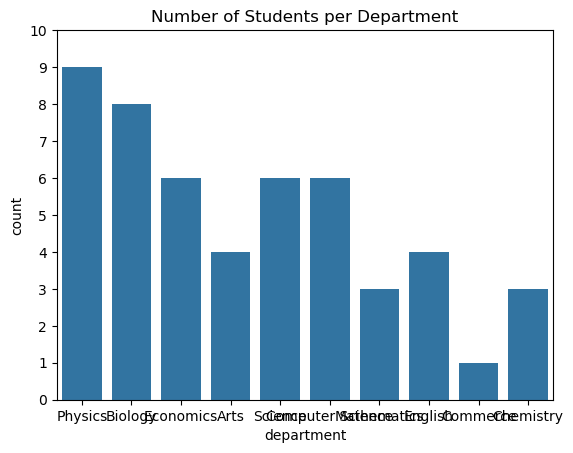

In [65]:
sns.countplot(x='department', data=copydf)

plt.title('Number of Students per Department')
plt.yticks(range(0, 11, 1))

plt.show()

## Problem 10

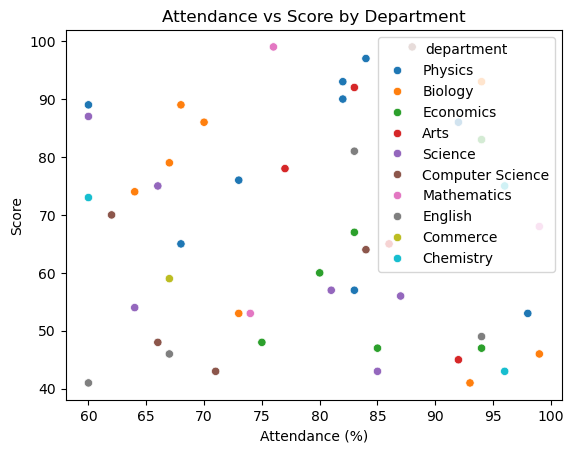

In [69]:
sns.scatterplot(data=copydf,x='attendance',y='score',hue='department')

plt.title("Attendance vs Score by Department")
plt.xlabel("Attendance (%)")
plt.ylabel("Score")

plt.show()